## Initiate and Dataset

In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass  
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle
Draw.DrawingOptions.atomLabelFontFace = "DejaVu Sans"
Draw.DrawingOptions.atomLabelFontSize = 18




UsageError: Line magic function `%autoreload` not found.


In [2]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the  test sets from SDF files
test_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Oral toxicity\dataset\test_set_acute_oral_features_rdkitcdk.sdf')

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string


test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

def string_to_list(descriptor):
    if isinstance(descriptor, str):
        return list(map(float, descriptor.strip('[]').split(',')))
    return descriptor

# Apply the function to the 'Modred_Descriptor' column
test_df['Modred_Descriptor'] = test_df['Modred_Descriptor'].apply(string_to_list)

# Convert 'Modred_Descriptor' column to a NumPy array
data_modred_test = np.array(test_df['Modred_Descriptor'].tolist())


print("Test DataFrame:")
print(test_df.head())


Test DataFrame:
         CASRN          DTXSID  \
0   98119-87-0  DTXSID20243457   
1    1504-74-1             nan   
2     303-45-7   DTXSID5023110   
3  173159-57-4   DTXSID7034753   
4     100-53-8   DTXSID6026664   

                                                Name     Structure_Source  \
0  Benzoic acid, 2,2'-((1,3-dioxo-2-(phenylmethyl...           EPA_DSSTox   
1                                                     Public_CrossChecked   
2                                           Gossypol           EPA_DSSTox   
3                                      Foramsulfuron           EPA_DSSTox   
4                                Benzenemethanethiol           EPA_DSSTox   

                                     Canonical_QSARr Salt_Solvent  \
0  OC(=O)C1=CC=CC=C1NC(=O)C(=CC1C=CC=CC=1)C(=O)NC...            ?   
1                                COC1C=CC=CC=1C=CC=O            ?   
2  CC1C=C2C(C(C=O)=C(O)C(O)=C2C(C)C)=C(O)C=1C1=C(...            ?   
3  CN(C)C(=O)C1C=CC(=CC=1S(=O)(=O)NC(=O)

## Explotary Data

In [3]:
test_df.keys()

Index(['CASRN', 'DTXSID', 'Name', 'Structure_Source', 'Canonical_QSARr',
       'Salt_Solvent', 'InChI_Code_QSARr', 'InChI Key_QSARr', 'very_toxic',
       'nontoxic', 'StandardizerResult', 'Outcome', 'ID', 'GHS_category',
       'EPA_category', 'LD50_mgkg', 'RowID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'SMILES', 'Molecular Weight',
       'logP', 'LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD',
       'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds',
       'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
       'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v',
       'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha',
       'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', '

In [4]:
test_df = test_df.rename(columns={'Outcome': 'Outcome'})

In [5]:
test_df = test_df[(test_df['Outcome']== '0')|(test_df['Outcome']== '1')]
test_df=test_df.sort_values(['Outcome'], ascending=True)


In [6]:
test_df = test_df.dropna()

In [7]:
test_df

,CASRN,DTXSID,Name,Structure_Source,Canonical_QSARr,Salt_Solvent,InChI_Code_QSARr,InChI Key_QSARr,very_toxic,nontoxic,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,98119-87-0,DTXSID20243457,"Benzoic acid, 2,2'-((1,3-dioxo-2-(phenylmethyl...",EPA_DSSTox,OC(=O)C1=CC=CC=C1NC(=O)C(=CC1C=CC=CC=1)C(=O)NC...,?,InChI=1S/C24H18N2O6/c27-21(25-19-12-6-4-10-16(...,RNVMJUCFJAEWSG-UHFFFAOYSA-N,FALSE,TRUE,...,4.0,3.0,5.0,0.5,9.0,1.0,132.79999999999998,6.08746284125034,5.680000000000002,0.0
849,85209-91-2,DTXSID2072914,"12H-Dibenzo[d,g][1,3,2]dioxaphosphocin, 2,4,8,...",EPA_DSSTox,CC(C)(C)C1=CC(=CC2CC3C=C(C=C(C=3OP(O)(=O)OC1=2...,[Na+],"InChI=1S/C29H43O4P/c1-26(2,3)20-14-18-13-19-15...",GGQHNQQPLWRNHD-UHFFFAOYSA-N,FALSE,TRUE,...,1.0,3.0,3.0,0.5,4.0,1.0,65.57000000000001,6.169925001442312,9.204000000000002,0.5862068965517241
852,106065-10-5,nan,,Public_CrossChecked,COCCCOCC(C)OCCCOC(=O)C1C=CC=CC=1,?,InChI=1S/C17H26O5/c1-15(14-20-11-6-10-19-2)21-...,BEVNMDIBCATXFZ-UHFFFAOYSA-N,FALSE,TRUE,...,0.0,3.0,15.0,0.4705882352941176,13.0,1.0,53.99,5.459431618637297,2.564,0.5882352941176471
855,19882-03-2,nan,,Public_CrossChecked,CCC12CCC3C(CCC4C=C(O)C=CC=43)C1CC(O)C2O,?,InChI=1S/C19H26O3/c1-2-19-8-7-14-13-6-4-12(20)...,KMVJBESLNMZCAQ-UHFFFAOYSA-N,FALSE,TRUE,...,3.0,2.0,2.0,0.5,1.0,0.0,60.69,5.643856189774724,4.2,0.6842105263157895
859,501-53-1,DTXSID9027158,Benzyl chloroformate,EPA_DSSTox,O=C(Cl)OCC1C=CC=CC=1,?,InChI=1S/C8H7ClO2/c9-8(10)11-6-7-4-2-1-3-5-7/h...,HSDAJNMJOMSNEV-UHFFFAOYSA-N,FALSE,TRUE,...,0.0,0.0,4.0,0.4285714285714285,3.0,0.0,26.3,4.459431618637298,2.3470000000000004,0.125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
932,64037-53-2,nan,,Public_CrossChecked,CC(Br)C=CCl,?,"InChI=1S/C4H6BrCl/c1-4(5)2-3-6/h2-4H,1H3",JBFROCOYMZXIFP-UHFFFAOYSA-N,FALSE,FALSE,...,0.0,4.0,5.0,0.5,1.0,0.0,0.0,3.321928094887362,2.7300000000000004,0.5
933,4095-32-3,nan,,Public_CrossChecked,CC(C)SSC(Cl)C(Cl)Cl,?,InChI=1S/C5H9Cl3S2/c1-3(2)9-10-5(8)4(6)7/h3-5H...,CCVBOQAQIZDRRY-UHFFFAOYSA-N,FALSE,FALSE,...,0.0,3.0,7.0,0.5,4.0,0.0,50.6,4.169925001442312,3.62,1.0
934,62751-72-8,DTXSID30211824,"1H-Indole-3-acetic acid, 1-(p-chlorobenzoyl)-5...",EPA_DSSTox,CC1=C(CC(=O)OCOC(=O)C2C=CC=CC=2)C2=CC(=CC=C2N1...,?,InChI=1S/C27H22ClNO6/c1-17-22(15-25(30)34-16-3...,SPOHBRIBTFAVAK-UHFFFAOYSA-N,FALSE,FALSE,...,0.0,2.0,7.0,0.5,10.0,1.0,83.83000000000001,6.247927513443585,5.6240000000000006,0.1481481481481481
920,75530-68-6,DTXSID2046624,Nilvadipine,EPA_DSSTox,CC1NC(C#N)=C(C(C=1C(=O)OC(C)C)C1=CC(=CC=C1)[N+...,?,InChI=1S/C19H19N3O6/c1-10(2)28-19(24)15-11(3)2...,FAIIFDPAEUKBEP-UHFFFAOYSA-N,FALSE,FALSE,...,1.0,3.0,5.0,0.5,7.0,0.0,131.56,5.857980995127573,3.688,0.3157894736842105


## Data Distribution

Classes                          :  ['0' '1']
Number of cpds in each class     :  [736 907]
Total number of cpds             :  1643


{'0': 0, '1': 1}

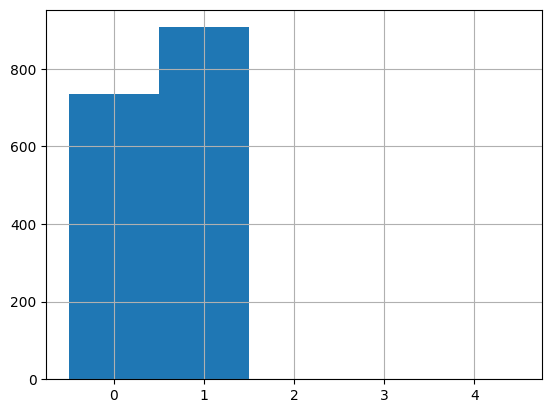

In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(test_df['Outcome']))
le.fit(list(set(outcomes)))
y = le.transform( test_df['Outcome'] )



print ("Classes                          : ",(outcomes))
print ("Number of cpds in each class     : ",np.unique([len(y[y==smi]) for smi in y]))
print ("Total number of cpds             : ",len(y))

S = test_df['Outcome']
info = {}
for i,cls in enumerate(S.unique()):
    info.update({cls:i})
    S = S.replace(cls,i)

#graph
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

## Data Cleansing and Preproc

In [9]:
x_rdkitcdk = test_df.drop(columns=['CASRN', 'DTXSID', 'Name', 'Structure_Source', 'Canonical_QSARr',
       'Salt_Solvent', 'InChI_Code_QSARr', 'InChI Key_QSARr', 'very_toxic',
       'nontoxic', 'StandardizerResult', 'Outcome', 'ID', 'GHS_category',
       'EPA_category', 'LD50_mgkg', 'RowID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'SMILES', 'Molecular Weight',
       'logP'])

In [10]:
print(x_rdkitcdk)

               LabuteASA                TPSA                 AMW  \
0      182.3799214576036  132.79999999999998   430.4160000000001   
849   206.25761700245897  55.760000000000005   486.6330000000003   
852   132.06146939593094               53.99  310.38999999999993   
855    131.5408584026532               60.69  302.41399999999993   
859    69.73962090472249                26.3  170.59500000000003   
...                  ...                 ...                 ...   
932   51.315288171358155                 0.0             169.449   
933    84.75500030314114                 0.0              239.62   
934   206.32945098727976   83.83000000000001  491.92700000000013   
920     160.936165635433              131.56   385.3760000000001   
1642  115.25144196623931              109.63  282.37300000000005   

     NumLipinskiHBA NumLipinskiHBD NumRotatableBonds NumHBD NumHBA  \
0                 4              4                 7      4      4   
849               3              1         

In [11]:
x_rdkitcdk  = x_rdkitcdk.apply(lambda row: row.values, axis=1).tolist()

# Add the new column 'rdkit_cdk' to test_df
test_df['rdkit_cdk'] = x_rdkitcdk 

# Display the updated DataFrame
print(test_df)

            CASRN          DTXSID  \
0      98119-87-0  DTXSID20243457   
849    85209-91-2   DTXSID2072914   
852   106065-10-5             nan   
855    19882-03-2             nan   
859      501-53-1   DTXSID9027158   
...           ...             ...   
932    64037-53-2             nan   
933     4095-32-3             nan   
934    62751-72-8  DTXSID30211824   
920    75530-68-6   DTXSID2046624   
1642   97817-39-5  DTXSID20243270   

                                                   Name     Structure_Source  \
0     Benzoic acid, 2,2'-((1,3-dioxo-2-(phenylmethyl...           EPA_DSSTox   
849   12H-Dibenzo[d,g][1,3,2]dioxaphosphocin, 2,4,8,...           EPA_DSSTox   
852                                                      Public_CrossChecked   
855                                                      Public_CrossChecked   
859                                Benzyl chloroformate           EPA_DSSTox   
...                                                 ...                  ..

## Data Initiate

In [12]:
y_test= np.int32((S))
x_test_morgan = np.array(list(test_df['Morgan_Descriptors']))
x_test_macckeys = np.array(list(test_df['MACCS_Descriptors']))
x_test_modred= np.array(list(test_df['Modred_Descriptor']))
x_test_rdkit_cdk = np.array(list(test_df['rdkit_cdk']))

In [13]:
x_test_rdkit_cdk

array([['182.3799214576036', '132.79999999999998', '430.4160000000001',
        ..., '6.08746284125034', '5.680000000000002', '0.0'],
       ['206.25761700245897', '55.760000000000005', '486.6330000000003',
        ..., '6.169925001442312', '9.204000000000002',
        '0.5862068965517241'],
       ['132.06146939593094', '53.99', '310.38999999999993', ...,
        '5.459431618637297', '2.564', '0.5882352941176471'],
       ...,
       ['206.32945098727976', '83.83000000000001', '491.92700000000013',
        ..., '6.247927513443585', '5.6240000000000006',
        '0.1481481481481481'],
       ['160.936165635433', '131.56', '385.3760000000001', ...,
        '5.857980995127573', '3.688', '0.3157894736842105'],
       ['115.25144196623931', '109.63', '282.37300000000005', ...,
        '5.321928094887363', '-0.984', '0.5454545454545454']],
      dtype=object)

In [14]:
import joblib
import numpy as np
import ast

# Function to ensure data is a NumPy array
def ensure_numpy_array(data):
    if isinstance(data, np.ndarray):
        return data
    elif isinstance(data, list):
        return np.array(data)
    elif hasattr(data, 'to_numpy'):  # For Pandas DataFrame
        return data.to_numpy()
    else:
        raise ValueError("Data format not recognized. Ensure it is a list, numpy array, or pandas DataFrame.")

# Function to check if all elements are numerical
def check_numerical(data):
    if not np.issubdtype(data.dtype, np.number):
        raise ValueError("Data contains non-numerical values. Ensure all elements are numerical.")

# Function to convert string representations of lists to numerical arrays
def parse_string_lists(data):
    parsed_data = []
    for item in data:
        if isinstance(item, str):
            try:
                parsed_item = ast.literal_eval(item)
                parsed_data.append(parsed_item)
            except (ValueError, SyntaxError):
                raise ValueError(f"Cannot parse value '{item}'")
        else:
            parsed_data.append(item)
    return np.array(parsed_data)

# Ensure training data is properly formatted
x_test_morgan = ensure_numpy_array(x_test_morgan)
x_test_macckeys = ensure_numpy_array(x_test_macckeys)
x_test_modred = ensure_numpy_array(x_test_modred)

check_numerical(x_test_morgan)
check_numerical(x_test_macckeys)

# Parse and convert string lists in x_test_modred
x_test_modred = parse_string_lists(x_test_modred)
check_numerical(x_test_modred)





In [15]:
x_test = np.concatenate((x_test_morgan, x_test_macckeys, x_test_modred), axis=1)

In [16]:
len(test_df['Modred_Descriptor'][0])

730

## Load .pkl Model

In [17]:
import joblib

# Path fingerprint descriptor model
base_path_fp = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Oral toxicity\model\fingerprint descriptor model"

# Path physical chemical properties model
base_path_phys = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Oral toxicity\model\physical chemical properties model"

# RF
rf_morgan = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_RF_morgan.pkl")
rf_maccs  = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_RF_maccskey.pkl")
rf_modred = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_RF_modred.pkl")
rf_p   = joblib.load(fr"{base_path_phys}\Model_Oral_toxicity_RF_phys.pkl")

# SVM
svm_morgan = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_SVM_morgan.pkl")
svm_maccs  = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_SVM_maccskey.pkl")
svm_modred = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_SVM_modred.pkl")
svm_p   = joblib.load(fr"{base_path_phys}\Model_Oral_toxicity_SVM_phys.pkl")

# XGB
xgb_morgan = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_XGB_morgan.pkl")
xgb_maccs  = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_XGB_maccskey.pkl")
xgb_modred = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_XGB_modred.pkl")
xgb_p   = joblib.load(fr"{base_path_phys}\Model_Oral_toxicity_XGB_phys.pkl")

# NN
nn_morgan = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_NN_morgan.pkl")
nn_maccs  = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_NN_maccskey.pkl")
nn_modred = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_NN_modred.pkl")
nn_p   = joblib.load(fr"{base_path_phys}\Model_Oral_toxicity_NN_phys.pkl")

# LGBM
lgbm_morgan = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_LGBM_morgan.pkl")
lgbm_maccs  = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_LGBM_maccskey.pkl")
lgbm_modred = joblib.load(fr"{base_path_fp}\Model_Oral_toxicity_LGBM_modred.pkl")
lgbm_p   = joblib.load(fr"{base_path_phys}\Model_Oral_toxicity_LGBM_phys.pkl")


In [18]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score, classification_report
y_true = test_df['Outcome'].astype(int)  # Ensure it's of integer type, suitable for metrics calculation


## XAI Feature Importance

In [22]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 56 fitur phys (sama dengan eye irritation)
oral_features = [
    'Molecular Weight', 'logP', 'LabuteASA', 'TPSA', 'AMW', 
    'NumLipinskiHBA', 'NumLipinskiHBD', 'NumRotatableBonds', 'NumHBD', 
    'NumHBA', 'NumAmideBonds', 'NumHeteroAtoms', 'NumAtoms', 'NumRings', 
    'NumAromaticRings', 'NumSaturatedRings', 'NumAliphaticRings', 
    'NumAromaticHeterocycles', 'NumSaturatedHeterocycles', 
    'NumAliphaticHeterocycles', 'NumAromaticCarbocycles', 
    'NumSaturatedCarbocycles', 'NumAliphaticCarbocycles', 'FractionCSP3', 
    'Chi0v', 'Chi1v', 'Chi2v', 'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 
    'Chi3n', 'Chi4n', 'HallKierAlpha', 'kappa1', 'kappa2', 'kappa3', 
    'ALogP', 'ALogP2', 'AMR', 'MLogP', 'nAtomP', 'naAromAtom', 'bpol', 
    'nB', 'ECCEN', 'fragC', 'nHBAcc', 'nHBDon', 'nAtomLAC', 'nAtomLC', 
    'PetitjeanNumber', 'nRotB', 'LipinskiFailures', 'TopoPSA', 'VAdjMat', 
    'XLogP', 'Fsp3'
]

# Verifikasi
missing = [f for f in oral_features if f not in test_df.columns]
print(f"Jumlah fitur : {len(oral_features)}")
print(f"Missing      : {len(missing)} → {missing}")

# Ambil fitur
X_oral = test_df[oral_features].copy().fillna(0)
print(f"Shape X_oral : {X_oral.shape}")  # harusnya (1643, 56)

# SHAP
explainer_oral = shap.TreeExplainer(rf_phys)
shap_values_oral = explainer_oral.shap_values(X_oral, check_additivity=False)
print("SHAP OK! Shape:", np.array(shap_values_oral).shape)

C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Jumlah fitur : 58
Missing      : 0 → []
Shape X_oral : (1643, 58)
SHAP OK! Shape: (1643, 58, 2)


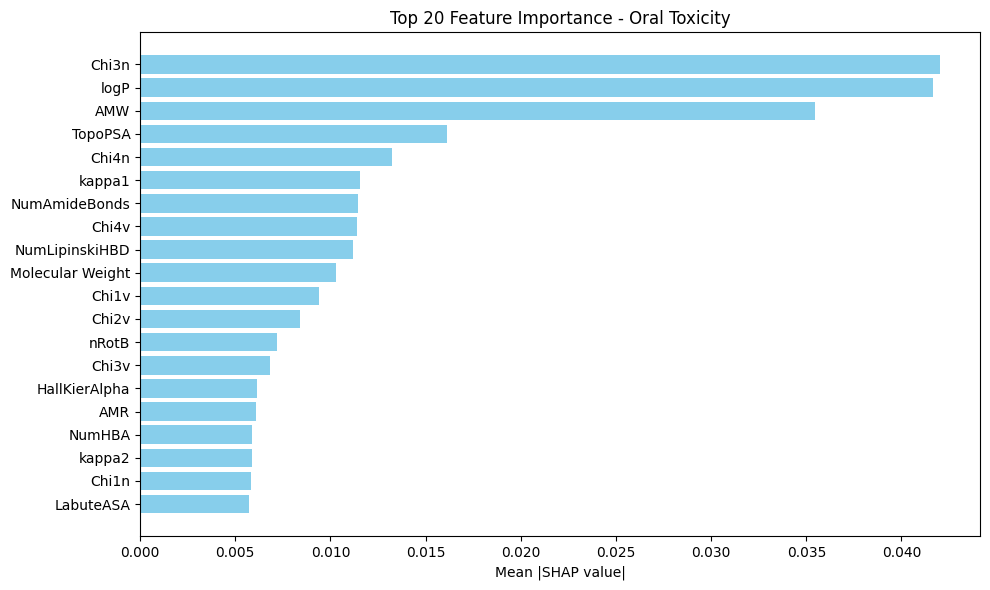

In [24]:
shap_vals_class1 = shap_values_oral[:, :, 1]
importance_vals = np.abs(shap_vals_class1).mean(axis=0)

importance_df = pd.DataFrame({
    "Feature": oral_features,
    "Importance": importance_vals
}).sort_values(by="Importance", ascending=False)

top20 = importance_df.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top20["Feature"], top20["Importance"], color="skyblue")
plt.gca().invert_yaxis()
plt.xlabel("Mean |SHAP value|")
plt.title("Top 20 Feature Importance - Oral Toxicity")
plt.tight_layout()
plt.show()

In [19]:
# Consensus with probability average 
# calculate probs form morgan, modred and macss 
#descriptor only

def predict_with_models_probabilities(moldf):
   
    morgan_probs = rf_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = rf_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = rf_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs], axis=0)
   # mean_probs = np.mean([morgan_probs, maccs_probs], axis=0)
   # mean_probs = np.mean([maccs_probs, modred_probs], axis=0)
    # Convert mean probabilities to final class predictions (e.g., threshold at 0.5)
    final_predictions = (mean_probs > 0.5).astype(int)
    
    return final_predictions

# Run prediction
final_predictions = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions

print(test_df[['SMILES', 'Predictions']])

                                                 SMILES  Predictions
0     O=C(Nc1ccccc1C(=O)O)C(=Cc1ccccc1)C(=O)Nc1ccccc...            0
849   CC(C)(C)c1cc2c(c(C(C)(C)C)c1)OP(=O)(O)Oc1c(cc(...            0
852                       COCCCOCC(C)OCCCOC(=O)c1ccccc1            0
855                  CCC12CCC3c4ccc(O)cc4CCC3C1CC(O)C2O            0
859                                   O=C(Cl)OCc1ccccc1            1
...                                                 ...          ...
932                                         CC(Br)C=CCl            1
933                                 CC(C)SSC(Cl)C(Cl)Cl            1
934   COc1ccc2c(c1)c(CC(=O)OCOC(=O)c1ccccc1)c(C)n2C(...            1
920   COC(=O)C1=C(C#N)NC(C)=C(C(=O)OC(C)C)C1c1cccc([...            1
1642                  CC(C)NC(=O)N1CCc2nc(N=C(N)N)sc2C1            1

[1643 rows x 2 columns]


## Physiochemical Consensus and Individual

In [19]:
#Default

import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):
  
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]  # Probabilities for class 1
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]  # Probabilities for class 1
    svm_probs_rdkitcdk = svm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]  # Probabilities for class 1
    
    # Calculate the mean probability across RF and XGB models
    mean_probs = np.mean([rf_probs_rdkitcdk, xgb_probs_rdkitcdk], axis=0)
    
    # Convert mean probabilities to final class predictions (e.g., threshold at 0.5)
    final_predictions = (mean_probs > 0.5).astype(int)
    
    return final_predictions, mean_probs, rf_probs_rdkitcdk, xgb_probs_rdkitcdk, svm_probs_rdkitcdk

# Run prediction
final_predictions, mean_probs, rf_probs, xgb_probs, svm_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
test_df['RF_Probabilities'] = rf_probs
test_df['XGB_Probabilities'] = xgb_probs
test_df['SVM_Probabilities'] = svm_probs

y_true = test_df['Outcome'].astype(int)  

conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix (Consensus):")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy (Consensus):", accuracy)

auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score (Consensus):", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')  
print("F1 Score (Consensus):", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity (Consensus):", sensitivity)
print("Specificity (Consensus):", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate) (Consensus):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp)
print("PPV (Positive Predictive Value) (Consensus):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn)
print("NPV (Negative Predictive Value) (Consensus):", npv)

# Evaluate RF model alone
rf_predictions = (rf_probs > 0.5).astype(int)
conf_matrix_rf = confusion_matrix(y_true, rf_predictions)
print("Confusion Matrix (RF):")
print(conf_matrix_rf)

accuracy_rf = accuracy_score(y_true, rf_predictions)
print("Accuracy (RF):", accuracy_rf)

auc_score_rf = roc_auc_score(y_true, rf_probs)
print("AUC Score (RF):", auc_score_rf)

f1_rf = f1_score(y_true, rf_predictions, average='binary')
print("F1 Score (RF):", f1_rf)

tn, fp, fn, tp = conf_matrix_rf.ravel()
sensitivity_rf = tp / (tp + fn)
specificity_rf = tn / (tn + fp)
print("Sensitivity (RF):", sensitivity_rf)
print("Specificity (RF):", specificity_rf)

ccr_rf = (sensitivity_rf + specificity_rf) / 2
print("CCR (Correct Classification Rate) (RF):", ccr_rf)

ppv_rf = tp / (tp + fp)
print("PPV (Positive Predictive Value) (RF):", ppv_rf)

npv_rf = tn / (tn + fn)
print("NPV (Negative Predictive Value) (RF):", npv_rf)

# Evaluate XGB model alone
xgb_predictions = (xgb_probs > 0.5).astype(int)
conf_matrix_xgb = confusion_matrix(y_true, xgb_predictions)
print("Confusion Matrix (XGB):")
print(conf_matrix_xgb)

accuracy_xgb = accuracy_score(y_true, xgb_predictions)
print("Accuracy (XGB):", accuracy_xgb)

auc_score_xgb = roc_auc_score(y_true, xgb_probs)
print("AUC Score (XGB):", auc_score_xgb)

f1_xgb = f1_score(y_true, xgb_predictions, average='binary')
print("F1 Score (XGB):", f1_xgb)

tn, fp, fn, tp = conf_matrix_xgb.ravel()
sensitivity_xgb = tp / (tp + fn)
specificity_xgb = tn / (tn + fp)
print("Sensitivity (XGB):", sensitivity_xgb)
print("Specificity (XGB):", specificity_xgb)

ccr_xgb = (sensitivity_xgb + specificity_xgb) / 2
print("CCR (Correct Classification Rate) (XGB):", ccr_xgb)

ppv_xgb = tp / (tp + fp)
print("PPV (Positive Predictive Value) (XGB):", ppv_xgb)

npv_xgb = tn / (tn + fn)
print("NPV (Negative Predictive Value) (XGB):", npv_xgb)

# Evaluate SVM model alone
svm_predictions = (svm_probs > 0.5).astype(int)
conf_matrix_svm = confusion_matrix(y_true, svm_predictions)
print("Confusion Matrix (SVM):")
print(conf_matrix_svm)

accuracy_svm = accuracy_score(y_true, svm_predictions)
print("Accuracy (SVM):", accuracy_svm)

auc_score_svm = roc_auc_score(y_true, svm_probs)
print("AUC Score (SVM):", auc_score_svm)

f1_svm = f1_score(y_true, svm_predictions, average='binary')
print("F1 Score (SVM):", f1_svm)

tn, fp, fn, tp = conf_matrix_svm.ravel()
sensitivity_svm = tp / (tp + fn)
specificity_svm = tn / (tn + fp)
print("Sensitivity (SVM):", sensitivity_svm)
print("Specificity (SVM):", specificity_svm)

ccr_svm = (sensitivity_svm + specificity_svm) / 2
print("CCR (Correct Classification Rate) (SVM):", ccr_svm)

ppv_svm = tp / (tp + fp)
print("PPV (Positive Predictive Value) (SVM):", ppv_svm)

npv_svm = tn / (tn + fn)
print("NPV (Negative Predictive Value) (SVM):", npv_svm)

Confusion Matrix (Consensus):
[[476 260]
 [183 724]]
Accuracy (Consensus): 0.7303712720632989
AUC Score (Consensus): 0.80539343751498
F1 Score (Consensus): 0.7657324167107351
Sensitivity (Consensus): 0.7982359426681367
Specificity (Consensus): 0.6467391304347826
CCR (Correct Classification Rate) (Consensus): 0.7224875365514596
PPV (Positive Predictive Value) (Consensus): 0.7357723577235772
NPV (Negative Predictive Value) (Consensus): 0.7223065250379362
Confusion Matrix (RF):
[[485 251]
 [187 720]]
Accuracy (RF): 0.7334144856968959
AUC Score (RF): 0.8029456881261685
F1 Score (RF): 0.7667731629392971
Sensitivity (RF): 0.7938257993384785
Specificity (RF): 0.6589673913043478
CCR (Correct Classification Rate) (RF): 0.7263965953214131
PPV (Positive Predictive Value) (RF): 0.741503604531411
NPV (Negative Predictive Value) (RF): 0.7217261904761905
Confusion Matrix (XGB):
[[475 261]
 [178 729]]
Accuracy (XGB): 0.7328058429701765
AUC Score (XGB): 0.7972322755380854
F1 Score (XGB): 0.768581971534

In [20]:
#best choice maybe
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):
    X_test = np.array(test_df['rdkit_cdk'].tolist())

    rf_probs = rf_p.predict_proba(X_test)[:, 1]
    xgb_probs = xgb_p.predict_proba(X_test)[:, 1]
    svm_probs = svm_p.predict_proba(X_test)[:, 1]
    nn_probs = nn_p.predict_proba(X_test)[:, 1]
    lgbm_probs = lgbm_p.predict_proba(X_test)[:, 1]

    # Calculate the mean probability across all 5 models
    mean_probs = np.mean([rf_probs, xgb_probs, svm_probs, nn_probs, lgbm_probs], axis=0)

    # Convert mean probabilities to final class predictions (threshold at 0.5)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs, rf_probs, xgb_probs, svm_probs, nn_probs, lgbm_probs

# Run prediction
final_predictions, mean_probs, rf_probs, xgb_probs, svm_probs, nn_probs, lgbm_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
test_df['RF_Probabilities'] = rf_probs
test_df['XGB_Probabilities'] = xgb_probs
test_df['SVM_Probabilities'] = svm_probs
test_df['NN_Probabilities'] = nn_probs
test_df['LGBM_Probabilities'] = lgbm_probs

y_true = test_df['Outcome'].astype(int)


def evaluate_model(y_true, probs, label):
    predictions = (probs > 0.5).astype(int)
    cm = confusion_matrix(y_true, predictions)
    print(f"Confusion Matrix ({label}):")
    print(cm)

    accuracy = accuracy_score(y_true, predictions)
    print(f"Accuracy ({label}):", accuracy)

    auc_score = roc_auc_score(y_true, probs)
    print(f"AUC Score ({label}):", auc_score)

    f1 = f1_score(y_true, predictions, average='binary')
    print(f"F1 Score ({label}):", f1)

    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    print(f"Sensitivity ({label}):", sensitivity)
    print(f"Specificity ({label}):", specificity)

    ccr = (sensitivity + specificity) / 2
    print(f"CCR (Correct Classification Rate) ({label}):", ccr)

    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"PPV (Positive Predictive Value) ({label}):", ppv)

    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    print(f"NPV (Negative Predictive Value) ({label}):", npv)

    print()  # spacer antar model
    return {
        "accuracy": accuracy, "auc": auc_score, "f1": f1,
        "sensitivity": sensitivity, "specificity": specificity,
        "ccr": ccr, "ppv": ppv, "npv": npv
    }


# Evaluate consensus and each individual model
results_consensus = evaluate_model(y_true, mean_probs, "Consensus")
results_rf = evaluate_model(y_true, rf_probs, "RF")
results_xgb = evaluate_model(y_true, xgb_probs, "XGB")
results_svm = evaluate_model(y_true, svm_probs, "SVM")
results_nn = evaluate_model(y_true, nn_probs, "NN")
results_lgbm = evaluate_model(y_true, lgbm_probs, "LGBM")

Confusion Matrix (Consensus):
[[469 267]
 [152 755]]
Accuracy (Consensus): 0.7449786975045648
AUC Score (Consensus): 0.8093167273860313
F1 Score (Consensus): 0.782789009849663
Sensitivity (Consensus): 0.8324145534729879
Specificity (Consensus): 0.6372282608695652
CCR (Correct Classification Rate) (Consensus): 0.7348214071712765
PPV (Positive Predictive Value) (Consensus): 0.738747553816047
NPV (Negative Predictive Value) (Consensus): 0.7552334943639292

Confusion Matrix (RF):
[[485 251]
 [187 720]]
Accuracy (RF): 0.7334144856968959
AUC Score (RF): 0.8029456881261685
F1 Score (RF): 0.7667731629392971
Sensitivity (RF): 0.7938257993384785
Specificity (RF): 0.6589673913043478
CCR (Correct Classification Rate) (RF): 0.7263965953214131
PPV (Positive Predictive Value) (RF): 0.741503604531411
NPV (Negative Predictive Value) (RF): 0.7217261904761905

Confusion Matrix (XGB):
[[475 261]
 [178 729]]
Accuracy (XGB): 0.7328058429701765
AUC Score (XGB): 0.7972322755380854
F1 Score (XGB): 0.7685819715

## Descriptor Consensus and Individual

In [24]:
# CONSENSUS DESCRIPTOR
# complete process and data of descriptor , available at file name "consensus descriptor" only
# all algorithm with trio descriptor

import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):
    # Probabilities dari masing-masing descriptor model
    rf_probs_morgan   = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    rf_probs_maccs    = rf_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    rf_probs_modred   = rf_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]

    svm_probs_morgan  = svm_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    svm_probs_maccs   = svm_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    svm_probs_modred  = svm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]

    xgb_probs_morgan  = xgb_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    xgb_probs_maccs   = xgb_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    xgb_probs_modred  = xgb_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]

    nn_probs_morgan   = nn_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    nn_probs_maccs    = nn_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    nn_probs_modred   = nn_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]

    lgbm_probs_morgan = lgbm_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    lgbm_probs_maccs  = lgbm_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    lgbm_probs_modred = lgbm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]

    # Konsensus: rata-rata semua probabilitas descriptor
    mean_probs = np.mean([
        rf_probs_morgan, rf_probs_maccs, rf_probs_modred,
        svm_probs_morgan, svm_probs_maccs, svm_probs_modred,
        xgb_probs_morgan, xgb_probs_maccs, xgb_probs_modred,
        nn_probs_morgan, nn_probs_maccs, nn_probs_modred,
        lgbm_probs_morgan, lgbm_probs_maccs, lgbm_probs_modred
    ], axis=0)

    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs

# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions']        = final_predictions
test_df['Mean_Probabilities'] = mean_probs

y_true = test_df['Outcome'].astype(int)

# Evaluasi konsensus descriptor
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix (Consensus Descriptor):")
print(conf_matrix)
print("Accuracy (Consensus Descriptor):", accuracy_score(y_true, final_predictions))
print("AUC Score (Consensus Descriptor):", roc_auc_score(y_true, mean_probs))
print("F1 Score (Consensus Descriptor):", f1_score(y_true, final_predictions))

tn, fp, fn, tp = conf_matrix.ravel()
print("Sensitivity (Consensus Descriptor):", tp/(tp+fn))
print("Specificity (Consensus Descriptor):", tn/(tn+fp))
print("CCR (Consensus Descriptor):", (tp/(tp+fn)+tn/(tn+fp))/2)
print("PPV (Consensus Descriptor):", tp/(tp+fp))
print("NPV (Consensus Descriptor):", tn/(tn+fn))


Confusion Matrix (Consensus Descriptor):
[[521 215]
 [148 759]]
Accuracy (Consensus Descriptor): 0.7790626902008521
AUC Score (Consensus Descriptor): 0.8618444705431187
F1 Score (Consensus Descriptor): 0.8070175438596491
Sensitivity (Consensus Descriptor): 0.836824696802646
Specificity (Consensus Descriptor): 0.7078804347826086
CCR (Consensus Descriptor): 0.7723525657926273
PPV (Consensus Descriptor): 0.7792607802874744
NPV (Consensus Descriptor): 0.7787742899850523


## Consensus Physiochemmical and Mol Desc

In [21]:
#Persis dengan bu yunen
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = rf_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = rf_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs, xgb_probs_rdkitcdk], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
y_true = test_df['Outcome'].astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

# Calculate AUC using mean probabilities
auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[506 230]
 [144 763]]
Accuracy: 0.7723676202069385
AUC Score: 0.861309680743972
F1 Score: 0.8031578947368421
Sensitivity: 0.8412348401323043
Specificity: 0.6875
CCR (Correct Classification Rate): 0.7643674200661521
PPV (Positive Predictive Value): 0.7683786505538771
NPV (Negative Predictive Value): 0.7784615384615384


## RF XGB SVM

In [22]:
#rf xgb svm(p) rf(p)
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = xgb_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = svm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs, xgb_probs_rdkitcdk], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
y_true = test_df['Outcome'].astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

# Calculate AUC using mean probabilities
auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[522 214]
 [150 757]]
Accuracy: 0.7784540474741327
AUC Score: 0.8634053976319447
F1 Score: 0.8061767838125665
Sensitivity: 0.834619625137817
Specificity: 0.7092391304347826
CCR (Correct Classification Rate): 0.7719293777862998
PPV (Positive Predictive Value): 0.7796086508753862
NPV (Negative Predictive Value): 0.7767857142857143


## RF XGB SVM LGBM NN

In [23]:
#best
# rf xgb svm nn(p) lgbm(p)
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = xgb_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = svm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    nn_probs_rdkitcdk = nn_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs_rdkitcdk = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs, lgbm_probs_rdkitcdk , nn_probs_rdkitcdk], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
y_true = test_df['Outcome'].astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

# Calculate AUC using mean probabilities
auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[513 223]
 [140 767]]
Accuracy: 0.7790626902008521
AUC Score: 0.8634638200469776
F1 Score: 0.8086452293094359
Sensitivity: 0.8456449834619625
Specificity: 0.6970108695652174
CCR (Correct Classification Rate): 0.77132792651359
PPV (Positive Predictive Value): 0.7747474747474747
NPV (Negative Predictive Value): 0.7856049004594181


## Best Algorithm - RF XGB LGBM

In [24]:
#rf xgb svm(p) rf(p)
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = lgbm_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = lgbm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs_rdkitcdk = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]


    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs,lgbm_probs_rdkitcdk ,lgbm_probs_rdkitcdk, rf_probs_rdkitcdk], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
y_true = test_df['Outcome'].astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

# Calculate AUC using mean probabilities
auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[523 213]
 [163 744]]
Accuracy: 0.7711503347534997
AUC Score: 0.8519171540194621
F1 Score: 0.7982832618025751
Sensitivity: 0.8202866593164277
Specificity: 0.7105978260869565
CCR (Correct Classification Rate): 0.7654422427016921
PPV (Positive Predictive Value): 0.7774294670846394
NPV (Negative Predictive Value): 0.7623906705539358


## Read Accross

In [ ]:
test_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Oral toxicity\dataset\test_set_acute_oral_features_rdkitcdk.sdf')


In [26]:
#Read-Across (Tanimoto Similarity, Morgan Fingerprint, k=5, weighted) - Oral

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
from rdkit import DataStructs
from rdkit.DataStructs import ExplicitBitVect

# ===== Load train_df =====
train_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Oral toxicity\dataset\test_set_acute_oral_features_rdkitcdk.sdf')

def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string


train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)

print("Train DataFrame:")
print(train_df.head())
print(train_df.shape)


# ===== Fungsi Read-Across =====
def tanimoto_similarity_matrix(query_fps, ref_fps):
    n_query = query_fps.shape[0]
    n_ref = ref_fps.shape[0]
    sim_matrix = np.zeros((n_query, n_ref))

    ref_bitvecs = []
    for row in ref_fps:
        bv = ExplicitBitVect(len(row))
        on_bits = np.where(row == 1)[0].tolist()
        bv.SetBitsFromList(on_bits)
        ref_bitvecs.append(bv)

    for i, q_row in enumerate(query_fps):
        q_bv = ExplicitBitVect(len(q_row))
        q_on_bits = np.where(q_row == 1)[0].tolist()
        q_bv.SetBitsFromList(q_on_bits)
        sims = DataStructs.BulkTanimotoSimilarity(q_bv, ref_bitvecs)
        sim_matrix[i, :] = sims

    return sim_matrix


def read_across_predict(X_test_fp, X_train_fp, y_train, k=5):
    sim_matrix = tanimoto_similarity_matrix(X_test_fp, X_train_fp)
    predictions_proba = np.zeros(X_test_fp.shape[0])

    for i in range(X_test_fp.shape[0]):
        sims = sim_matrix[i, :]
        top_k_idx = np.argsort(sims)[::-1][:k]
        top_k_sims = sims[top_k_idx]
        top_k_labels = y_train[top_k_idx]

        total_sim = np.sum(top_k_sims)
        if total_sim > 0:
            weighted_pred = np.sum(top_k_sims * top_k_labels) / total_sim
        else:
            weighted_pred = np.mean(top_k_labels)
        predictions_proba[i] = weighted_pred

    return predictions_proba


# ===== Siapkan data =====
X_train_morgan = np.array(train_df['Morgan_Descriptors'].tolist())
y_train = pd.to_numeric(train_df['Outcome'], errors='coerce').astype(int).values

X_test_morgan = np.array(test_df['Morgan_Descriptors'].tolist())
y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

# ===== Jalankan read-across =====
readacross_probs = read_across_predict(X_test_morgan, X_train_morgan, y_train, k=5)
readacross_predictions = (readacross_probs > 0.5).astype(int)

test_df['ReadAcross_Probabilities'] = readacross_probs
test_df['ReadAcross_Predictions'] = readacross_predictions

# ===== Evaluasi =====
conf_matrix_ra = confusion_matrix(y_true, readacross_predictions)
print("Confusion Matrix (Read-Across):")
print(conf_matrix_ra)

accuracy_ra = accuracy_score(y_true, readacross_predictions)
print("Accuracy (Read-Across):", accuracy_ra)

auc_score_ra = roc_auc_score(y_true, readacross_probs)
print("AUC Score (Read-Across):", auc_score_ra)

f1_ra = f1_score(y_true, readacross_predictions, average='binary')
print("F1 Score (Read-Across):", f1_ra)

tn, fp, fn, tp = conf_matrix_ra.ravel()
sensitivity_ra = tp / (tp + fn)
specificity_ra = tn / (tn + fp)
print("Sensitivity (Read-Across):", sensitivity_ra)
print("Specificity (Read-Across):", specificity_ra)

ccr_ra = (sensitivity_ra + specificity_ra) / 2
print("CCR (Correct Classification Rate) (Read-Across):", ccr_ra)

ppv_ra = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value) (Read-Across):", ppv_ra)

npv_ra = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value) (Read-Across):", npv_ra)

Train DataFrame:
         CASRN          DTXSID  \
0   98119-87-0  DTXSID20243457   
1    1504-74-1             nan   
2     303-45-7   DTXSID5023110   
3  173159-57-4   DTXSID7034753   
4     100-53-8   DTXSID6026664   

                                                Name     Structure_Source  \
0  Benzoic acid, 2,2'-((1,3-dioxo-2-(phenylmethyl...           EPA_DSSTox   
1                                                     Public_CrossChecked   
2                                           Gossypol           EPA_DSSTox   
3                                      Foramsulfuron           EPA_DSSTox   
4                                Benzenemethanethiol           EPA_DSSTox   

                                     Canonical_QSARr Salt_Solvent  \
0  OC(=O)C1=CC=CC=C1NC(=O)C(=CC1C=CC=CC=1)C(=O)NC...            ?   
1                                COC1C=CC=CC=1C=CC=O            ?   
2  CC1C=C2C(C(C=O)=C(O)C(O)=C2C(C)C)=C(O)C=1C1=C(...            ?   
3  CN(C)C(=O)C1C=CC(=CC=1S(=O)(=O)NC(=O

## QRASAR Morgan

In [28]:
#rf xgb svm(p) rf(p) + read-across
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
from rdkit import DataStructs
from rdkit.DataStructs import ExplicitBitVect

# ===== Fungsi Read-Across =====
def tanimoto_similarity_matrix(query_fps, ref_fps):
    n_query = query_fps.shape[0]
    n_ref = ref_fps.shape[0]
    sim_matrix = np.zeros((n_query, n_ref))

    ref_bitvecs = []
    for row in ref_fps:
        bv = ExplicitBitVect(len(row))
        on_bits = np.where(row == 1)[0].tolist()
        bv.SetBitsFromList(on_bits)
        ref_bitvecs.append(bv)

    for i, q_row in enumerate(query_fps):
        q_bv = ExplicitBitVect(len(q_row))
        q_on_bits = np.where(q_row == 1)[0].tolist()
        q_bv.SetBitsFromList(q_on_bits)
        sims = DataStructs.BulkTanimotoSimilarity(q_bv, ref_bitvecs)
        sim_matrix[i, :] = sims

    return sim_matrix


def read_across_predict(X_test_fp, X_train_fp, y_train, k=5):
    sim_matrix = tanimoto_similarity_matrix(X_test_fp, X_train_fp)
    predictions_proba = np.zeros(X_test_fp.shape[0])

    for i in range(X_test_fp.shape[0]):
        sims = sim_matrix[i, :]
        top_k_idx = np.argsort(sims)[::-1][:k]
        top_k_sims = sims[top_k_idx]
        top_k_labels = y_train[top_k_idx]

        total_sim = np.sum(top_k_sims)
        if total_sim > 0:
            weighted_pred = np.sum(top_k_sims * top_k_labels) / total_sim
        else:
            weighted_pred = np.mean(top_k_labels)
        predictions_proba[i] = weighted_pred

    return predictions_proba


# ===== Fungsi konsensus utama =====
def predict_with_models_probabilities(test_df, train_df, k_readacross=5):
    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = lgbm_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = lgbm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs_rdkitcdk = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # ----- Read-Across -----
    X_train_morgan = np.array(train_df['Morgan_Descriptors'].tolist())
    y_train_ra = pd.to_numeric(train_df['Outcome'], errors='coerce').astype(int).values
    X_test_morgan = np.array(test_df['Morgan_Descriptors'].tolist())

    readacross_probs = read_across_predict(X_test_morgan, X_train_morgan, y_train_ra, k=k_readacross)

    # ----- Konsensus (7 komponen) -----
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs,lgbm_probs_rdkitcdk, xgb_probs_rdkitcdk, rf_probs_rdkitcdk,
    readacross_probs,readacross_probs
    ], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs, readacross_probs


# Run prediction
final_predictions, mean_probs, readacross_probs = predict_with_models_probabilities(test_df, train_df, k_readacross=5)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
test_df['ReadAcross_Probabilities'] = readacross_probs

y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[581 155]
 [118 789]]
Accuracy: 0.8338405356055996
AUC Score: 0.9215207204831984
F1 Score: 0.8525121555915721
Sensitivity: 0.8699007717750827
Specificity: 0.7894021739130435
CCR (Correct Classification Rate): 0.8296514728440632
PPV (Positive Predictive Value): 0.8358050847457628
NPV (Negative Predictive Value): 0.8311874105865522


## XAI

In [ ]:
'LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD', 'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds', 'NumHeteroAtoms',
'NumAtoms', 'NumRings', 'NumAromaticRings', 'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles', 'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles', 'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v', 'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n',
'Chi4n', 'HallKierAlpha', 'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', 'MLogP', 'nAtomP',
'naAromAtom', 'bpol', 'nB', 'ECCEN', 'fragC', 'nHBAcc', 'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber',
'nRotB', 'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3'

Dtype setelah konversi:
float64    56
dtype: int64
Shape: (1643, 56)

Menghitung SHAP values XGB...
Type: <class 'numpy.ndarray'>
Shape: (1643, 56)
Shape final: (1643, 56)


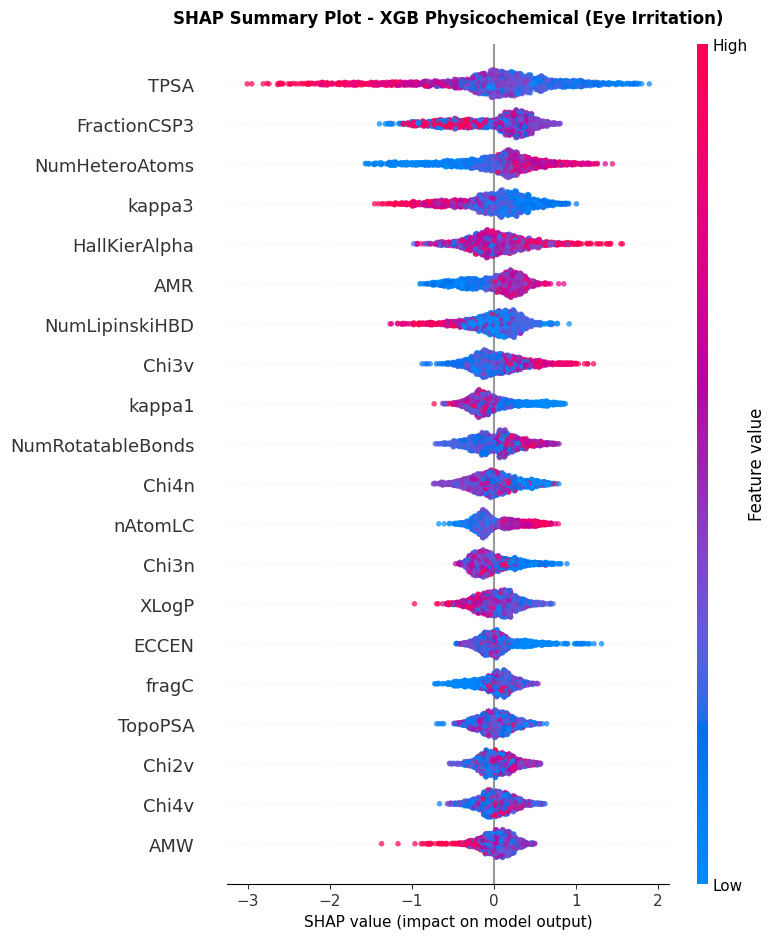

Plot tersimpan: shap_Oral.png


In [20]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feature_names = ['LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD', 'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds', 'NumHeteroAtoms',
'NumAtoms', 'NumRings', 'NumAromaticRings', 'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles', 'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles', 'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v', 'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n',
'Chi4n', 'HallKierAlpha', 'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', 'MLogP', 'nAtomP',
'naAromAtom', 'bpol', 'nB', 'ECCEN', 'fragC', 'nHBAcc', 'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber',
'nRotB', 'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3'
]

# ===== FIX: konversi eksplisit ke float64 =====
X_phys = pd.DataFrame(
    np.array(x_test_rdkit_cdk, dtype=np.float64),
    columns=feature_names
)

# Verifikasi dtype
print("Dtype setelah konversi:")
print(X_phys.dtypes.value_counts())
print(f"Shape: {X_phys.shape}")

# ===== XGBoost SHAP =====
print("\nMenghitung SHAP values XGB...")
explainer_xgb = shap.TreeExplainer(xgb_p)
shap_values_xgb = explainer_xgb.shap_values(X_phys)

print(f"Type: {type(shap_values_xgb)}")
print(f"Shape: {np.array(shap_values_xgb).shape}")

shap_vals = np.array(shap_values_xgb)
if len(shap_vals.shape) == 3:
    shap_vals = shap_vals[:, :, 1]

print(f"Shape final: {shap_vals.shape}")

# ===== Summary Plot =====
plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_vals,
    X_phys,
    plot_type="dot",
    max_display=20,
    show=False,
    alpha=0.7
)
plt.title("SHAP Summary Plot - XGB Physicochemical (Eye Irritation)",
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel("SHAP value (impact on model output)", fontsize=11)
plt.tight_layout()
plt.savefig("shap_Oral.png", dpi=300, bbox_inches='tight')
plt.show()
print("Plot tersimpan: shap_Oral.png")

Dtype setelah konversi:
float64    56
dtype: int64
Shape: (1643, 56)

Menghitung SHAP values XGB...
Type: <class 'numpy.ndarray'>
Shape: (1643, 56)
Shape final: (1643, 56)


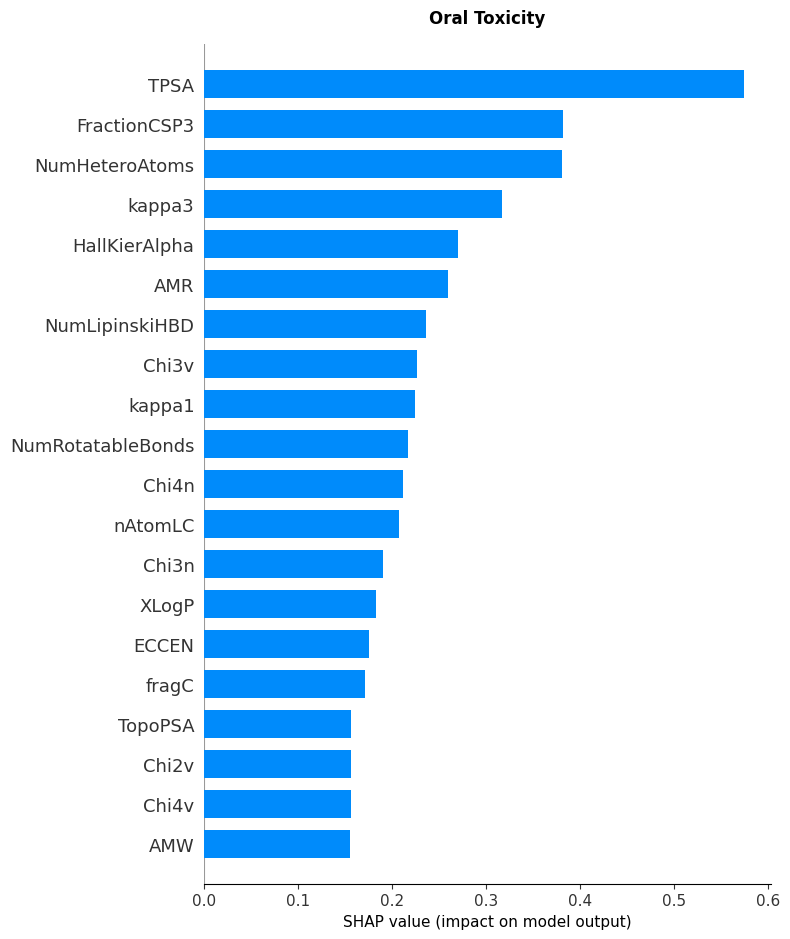

Plot tersimpan: shap_Oral.png


In [21]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feature_names = ['LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD', 'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds', 'NumHeteroAtoms',
'NumAtoms', 'NumRings', 'NumAromaticRings', 'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles', 'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles', 'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v', 'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n',
'Chi4n', 'HallKierAlpha', 'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', 'MLogP', 'nAtomP',
'naAromAtom', 'bpol', 'nB', 'ECCEN', 'fragC', 'nHBAcc', 'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber',
'nRotB', 'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3'
]

# ===== FIX: konversi eksplisit ke float64 =====
X_phys = pd.DataFrame(
    np.array(x_test_rdkit_cdk, dtype=np.float64),
    columns=feature_names
)

# Verifikasi dtype
print("Dtype setelah konversi:")
print(X_phys.dtypes.value_counts())
print(f"Shape: {X_phys.shape}")

# ===== XGBoost SHAP =====
print("\nMenghitung SHAP values XGB...")
explainer_xgb = shap.TreeExplainer(xgb_p)
shap_values_xgb = explainer_xgb.shap_values(X_phys)

print(f"Type: {type(shap_values_xgb)}")
print(f"Shape: {np.array(shap_values_xgb).shape}")

shap_vals = np.array(shap_values_xgb)
if len(shap_vals.shape) == 3:
    shap_vals = shap_vals[:, :, 1]

print(f"Shape final: {shap_vals.shape}")

# ===== Summary Plot =====
plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_vals,
    X_phys,
    plot_type="bar",
    max_display=20,
    show=False,
    alpha=0.7
)
plt.title("Oral Toxicity",
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel("SHAP value (impact on model output)", fontsize=11)
plt.tight_layout()
plt.savefig("shap_Oral_bar.png", dpi=300, bbox_inches='tight')
plt.show()
print("Plot tersimpan: shap_Oral.png")

## End of Revised